# 10: Results Summary (Luzon / Visayas / Mindanao, over time)

A capstone summary, not a new model: re-aggregates `04`'s existing cluster labels (`locality_clusters.parquet`) by island group (Luzon / Visayas / Mindanao) and by time window, to answer "what changed, where, and by how much" in one place instead of across eight notebooks.

This dataset has no demographic, survey, or motivational data -- only vote tallies. Every number below describes the shape of the recorded results (how lopsided a race was, how that share moved over time, where), not why any individual voted a given way. See **What this notebook cannot tell you** near the end.

## Island groups, not regions

`03`'s locality-level tables carry a `region` column (PSA's 17 administrative regions). This notebook maps those 17 regions to the 3 island groups using the standard grouping:

- **Luzon**: National Capital Region, Cordillera Administrative Region, Regions I-V
- **Visayas**: Regions VI-VIII
- **Mindanao**: Regions IX-XII, Caraga, BARMM

## Time windows

Philippine local elections run on a fixed 3-year cycle (2010, 2013, 2016, 2019, 2022, 2025), so a literal "last 2/5/10 years" window doesn't map onto election years. This notebook uses the closest equivalent by elections observed:

| Window | Elections included | Actual span |
|---|---|---|
| Full period | 2010, 2013, 2016, 2019, 2022, 2025 (all 6) | 15 years |
| Last ~10 years | 2016, 2019, 2022, 2025 (last 4) | 9 years |
| Most recent | 2022, 2025 (last 2) | 3 years |

A full per-election-year trend line is also shown below, since three window snapshots alone can miss a mid-period crossover (see Summary).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..") / "src"))

%matplotlib inline
pd.set_option("display.max_columns", 30)
print("pandas:", pd.__version__)

pandas: 3.0.2


In [2]:
CONFIG = {
    "processed_dir": "../data/processed",
}
processed_dir = Path(CONFIG["processed_dir"])

ISLAND_GROUP = {
    "NATIONAL CAPITAL REGION": "Luzon",
    "CORDILLERA ADMINISTRATIVE REGION": "Luzon",
    "REGION I": "Luzon", "REGION II": "Luzon", "REGION III": "Luzon",
    "REGION IV A": "Luzon", "REGION IV B": "Luzon", "REGION V": "Luzon",
    "REGION VI": "Visayas", "REGION VII": "Visayas", "REGION VIII": "Visayas",
    "REGION IX": "Mindanao", "REGION X": "Mindanao", "REGION XI": "Mindanao",
    "REGION XII": "Mindanao", "CARAGA": "Mindanao", "BARMM": "Mindanao",
}
ISLAND_ORDER = ["Luzon", "Visayas", "Mindanao"]
print(f"{len(ISLAND_GROUP)} regions mapped to {len(set(ISLAND_GROUP.values()))} island groups.")

17 regions mapped to 3 island groups.


## Load `04`'s cluster labels and attach island group

In [3]:
clusters = pd.read_parquet(processed_dir / "locality_clusters.parquet")
clusters["island_group"] = clusters["region"].map(ISLAND_GROUP)

assert clusters["island_group"].notna().all(), "Every region should map to an island group"
print(f"{len(clusters):,} locality-years, {clusters['region'].nunique()} regions, "
      f"{clusters['island_group'].nunique()} island groups.")
display(clusters.groupby("island_group").size().rename("n_locality_years").to_frame())

8,967 locality-years, 17 regions, 3 island groups.


,n_locality_years
island_group,
Luzon,4267
Mindanao,2379
Visayas,2321


## Landslide share by island group, three windows

"Landslide share" = same definition as `04`/`09`: fraction of locality-years in `04`'s landslide cluster (lopsided Mayor/Vice-Mayor/Councilor margin) vs. the competitive cluster. Computed independently per window.

In [4]:
def landslide_share_by_group(df):
    return (df.groupby("island_group")["cluster"]
            .apply(lambda s: (s == 0).mean() * 100)
            .reindex(ISLAND_ORDER)
            .round(1))

windows = {
    "Full period (2010-2025, 6 elections)": clusters,
    "Last ~10 years (2016-2025, 4 elections)": clusters[clusters["year"] >= 2016],
    "Most recent (2022-2025, 2 elections)": clusters[clusters["year"] >= 2022],
}

summary = pd.DataFrame({label: landslide_share_by_group(df) for label, df in windows.items()})
summary.index.name = "island_group"
display(summary)

counts = pd.DataFrame({label: df.groupby("island_group").size().reindex(ISLAND_ORDER)
                        for label, df in windows.items()})
print("\nLocality-years behind each figure (sample size, not a rate):")
display(counts)

,"Full period (2010-2025, 6 elections)","Last ~10 years (2016-2025, 4 elections)","Most recent (2022-2025, 2 elections)"
island_group,,,
Luzon,25.5,27.9,28.2
Visayas,29.1,33.5,37.4
Mindanao,34.4,36.1,36.9



Locality-years behind each figure (sample size, not a rate):


,"Full period (2010-2025, 6 elections)","Last ~10 years (2016-2025, 4 elections)","Most recent (2022-2025, 2 elections)"
island_group,,,
Luzon,4267,3080,1541
Visayas,2321,1632,816
Mindanao,2379,1818,913


## The actual trend, year by year

The three-window table above is three snapshots. This shows every one of the six elections, not just the endpoints.

island_group,Luzon,Visayas,Mindanao
year,,,
2010,13.6,16.8,24.4
2013,23.0,19.9,31.2
2016,26.0,26.5,37.1
2019,29.1,32.8,33.6
2022,24.3,31.9,32.7
2025,32.2,42.9,41.0


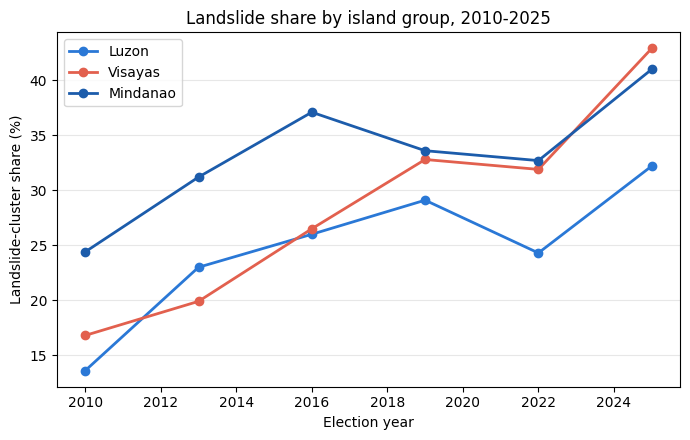

Change from 2010 to 2025, by island group (percentage points):


,pts_change_2010_to_2025
island_group,
Luzon,18.6
Visayas,26.1
Mindanao,16.6


In [5]:
trend = (clusters.groupby(["year", "island_group"])["cluster"]
          .apply(lambda s: (s == 0).mean() * 100)
          .unstack()[ISLAND_ORDER]
          .round(1))
display(trend)

colors = {"Luzon": "#2a78d6", "Visayas": "#e2604e", "Mindanao": "#1c5cab"}
fig, ax = plt.subplots(figsize=(7, 4.5))
for group in ISLAND_ORDER:
    ax.plot(trend.index, trend[group], marker="o", label=group,
            color=colors[group], linewidth=2)
ax.set_xlabel("Election year")
ax.set_ylabel("Landslide-cluster share (%)")
ax.set_title("Landslide share by island group, 2010-2025")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Change from 2010 to 2025, by island group (percentage points):")
display((trend.loc[2025] - trend.loc[2010]).round(1).rename("pts_change_2010_to_2025").to_frame())

## Grouped comparison across the three windows

Same numbers as the summary table above, drawn side by side: rising in every island group as the window narrows toward the present.

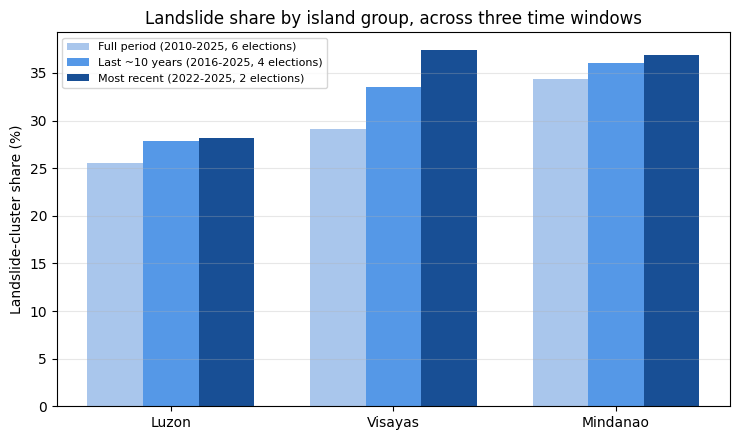

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(ISLAND_ORDER))
width = 0.25
window_colors = ["#a9c6ec", "#5598e7", "#184f95"]

for i, (label, col) in enumerate(zip(windows.keys(), summary.columns)):
    ax.bar(x + (i - 1) * width, summary[col], width, label=label, color=window_colors[i])

ax.set_xticks(x)
ax.set_xticklabels(ISLAND_ORDER)
ax.set_ylabel("Landslide-cluster share (%)")
ax.set_title("Landslide share by island group, across three time windows")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Sanity checks

Cross-checked against `04`'s headline numbers: `04` reported a 28.8% national landslide share and a 51.7% BARMM figure. BARMM is one region within the Mindanao group here, not the whole group, so the two numbers are expected to differ.

In [7]:
national_check = (clusters["cluster"] == 0).mean() * 100
print(f"National landslide share recomputed here: {national_check:.1f}% "
      f"(04 reported 28.8% -- {'match' if abs(national_check - 28.8) < 0.1 else 'MISMATCH, investigate'}).")

barmm_check = (clusters.loc[clusters['region'] == 'BARMM', 'cluster'] == 0).mean() * 100
print(f"BARMM-only landslide share recomputed here: {barmm_check:.1f}% "
      f"(04 reported 51.7% -- {'match' if abs(barmm_check - 51.7) < 0.1 else 'MISMATCH, investigate'}); "
      f"the Mindanao *group* figure above is lower because it also includes four other, "
      f"less landslide-heavy regions (Regions IX-XII, Caraga).")

assert summary.isna().sum().sum() == 0, "Every window should have a value for every island group"
assert (counts.sum() == pd.Series({k: len(v) for k, v in windows.items()})).all(), \
    "Window locality-year counts should sum to each window's own total"
print("\nAll sanity checks passed.")

National landslide share recomputed here: 28.8% (04 reported 28.8% -- match).
BARMM-only landslide share recomputed here: 51.7% (04 reported 51.7% -- match); the Mindanao *group* figure above is lower because it also includes four other, less landslide-heavy regions (Regions IX-XII, Caraga).

All sanity checks passed.


## What this notebook cannot tell you

Every figure above answers "what fraction of recorded races looked lopsided, where, and when" -- never "why." This dataset is vote tallies only: no exit polls, demographic breakdowns, stated reasons, candidate platforms, or campaign spending. A rising landslide share in a region could reflect a popular incumbent, a weak opposition bench, political-dynasty consolidation, or a less competitive candidate field election to election -- this data can't distinguish between them.

## Save

In [8]:
trend_out = trend.reset_index().melt(id_vars="year", var_name="island_group", value_name="landslide_share_pct")
trend_out.to_parquet(processed_dir / "island_group_trend.parquet", index=False)
print("Saved island_group_trend.parquet:", trend_out.shape)

summary_out = summary.reset_index()
summary_out.to_parquet(processed_dir / "island_group_window_summary.parquet", index=False)
print("Saved island_group_window_summary.parquet:", summary_out.shape)

Saved island_group_trend.parquet: (18, 3)
Saved island_group_window_summary.parquet: (3, 4)


## Summary

Landslide share rose in all three island groups since 2010: Luzon 13.6% to 32.2%, Visayas 16.8% to 42.9%, Mindanao 24.4% to 41.0%. Mindanao led for most of the period, consistent with `04`'s BARMM-specific finding, but Visayas overtook it by 2025 -- a crossover the three-window snapshot table alone would have missed, which is why the year-by-year trend line is shown. The direction is consistent across all three groups and windows, but no significance test is run on it here (unlike `08`), and this notebook doesn't attempt to explain the cause of the trend, only its size and direction.

**Out of scope here:** a statistical significance test on the trend (natural follow-up, `08`-style); a per-province breakdown within an island group (`09`'s map already covers this); any explanation beyond what the vote-share data itself supports.